# Solver Flow Explained — PD 토크 제어에서 전기–기계 연립 ODE 로

**누구를 위해.** 기계공학 배경의 동료가 한 번에 따라올 수 있도록 썼다.
전기회로 용어와 MuJoCo 내부 용어는 등장할 때마다 한 줄 해설을 붙이고,
필요한 최소 사전은 바로 다음 §0.5 에 몰아두었다.

**무엇을 보여주나.** 로봇 관절 제어를 "PD 로 계산한 토크를 바로 꽂기" 에서
"모터 전기식과 기계식을 연립으로 풀기" 로 확장한 뒤, 같은 수식을 구현한
세 가지 코드 경로가 **건강한 모터에서는 수치적으로 일치** 하고
**모터 결함 주입 시 표준 MuJoCo 경로만 발산** 한다는 것을 눈으로 확인한다.

**왜 중요한가.** 최근 감자(모터 자석이 약해져 $K_e$ 가 감소하는 결함)를 주입해 봤더니
결과가 이상해서 파보니 — "우리가 쓴다고 믿은 커스텀 솔버 코드가 실제론 꺼져 있었다"
는 버그였다. 이 노트북의 §6 이 그 수정이 제대로 됐다는 **시각적 증거**.

**세 가지 코드 경로.**

| 이름 | 위치 | 역할 |
|---|---|---|
| **2×2 backward Euler** (`coupled_ode_solver.py`) | Python 레퍼런스 | "수학적으로 맞는 답" 기준선 |
| **mjwarp patched filterexact** (`mujoco_warp/.../forward.py`) | 학습 런타임 (GPU) | 실제 RL 학습이 쓰는 경로 |
| **CPU implicit logger** (`solver_trace_logger.py`) | 설명용 | 행렬 블록 구조를 눈으로 보게 |

> mjwarp = MuJoCo 의 GPU(워프) 버전. MuJoCo = 이 노트북이 돌리는 CPU 엔진.
> 둘은 같은 ODE 를 풀지만 내부 적분 방식이 살짝 다르다 — §3 에서 왜 그래도
> 결과가 같은지 본다.

**실행 환경 주의.** 이 노트북의 모든 코드 셀은 **표준 MuJoCo CPU** 로 돈다.
GPU 학습 스택 전체를 띄우지 않고도 동일 수식을 재현할 수 있도록, mjwarp 패치 커널의
동작을 CPU 경로에서 **수학적으로 등가 재현**한다 (방법은 §5.1 에 설명).


## §0.5 미니 사전 — 이 노트북에서 쓰는 기호와 용어

(전공자라도 전기공학·수치해석·MuJoCo 용어는 헷갈릴 수 있으니 이 페이지를 책갈피처럼 쓰면 된다.)

### 기호 대응표

| 기호 | 의미 | 단위 | 메모 |
|---|---|---|---|
| $q,\;\dot q,\;\ddot q$ | 관절 각도 / 각속도 / 각가속도 | rad, rad/s, rad/s² | 기계동역학 그대로 |
| $\omega = g_r \dot q$ | 모터 축 회전 속도 | rad/s | 감속비 $g_r$ 로 관절 → 모터 변환 |
| $\tau$ | 관절 토크 | N·m | PD 로 명령되거나 $K_t g_r I$ 로 생성 |
| $I$ | 모터 **전류** | A | MuJoCo 내부에선 `d.act` 슬롯에 저장 |
| $V$ | 모터 **전압** | V | 모터 드라이버가 인가 |
| $R,\;L$ | 권선 저항 / 인덕턴스 | Ω, H | 모터 전기회로 상수 |
| $K_t$ | 토크 상수 | N·m/A | $\tau = K_t g_r I$ |
| $K_e$ | 역기전력 상수 | V·s/rad | $V_{\text{emf}} = K_e g_r \omega$. DC 모터에선 SI 단위로 $K_e = K_t$ |
| $M(q)$ | 로봇 질량 행렬 | kg·m² | $M(q)\ddot q + h(q,\dot q) = J^\top \tau$ |
| $h(q,\dot q)$ | Coriolis + 중력 + 마찰 | N·m | 기계동역학의 "비선형 잡동사니" |
| $\tau_e = L/R$ | 전기 시상수 | s | 전류가 step 입력에 반응하는 특성 시간 |

### 전기공학 최소 복습
- **역기전력 (back-EMF).** 모터가 회전하면 발전기처럼 $V_{\text{emf}} = K_e g_r \omega$
  를 스스로 만들어 인가 전압을 **깎아먹는다**. 그래서 모터 전기식이
  $L\dot I = V - R I - K_e g_r \omega$ 가 된다.
- **피드포워드 (feedforward).** 제어기가 "이만큼 역기전력이 생길 테니 미리 더해서
  전압을 인가하자" 고 보정하는 것. 건강한 모터에서는 역기전력을 정확히 상쇄해 제어기는
  사실상 "원하는 전류 = 인가 전류" 처럼 행동할 수 있다. RC 근사가 healthy 에서는 안 들키는
  이유가 바로 이것.

### 수치해석 최소 사전
- **forward (explicit) Euler.** 새 값 = 옛 값 + $\Delta t\cdot$(옛 값으로 계산한 도함수).
  간단하지만 stiff (시상수 짧은) 식엔 약함 → $\Delta t$ 를 작게 잡아야 안 터진다.
- **backward (implicit) Euler.** 새 값 = 옛 값 + $\Delta t\cdot$(**새 값**으로 계산한 도함수).
  방정식을 풀어야 하지만 stiff 식에 안정. 전기식은 $\tau_e \sim$ 수백 μs 로 짧아 stiff 이므로
  backward 가 제격.
- **exact 지수 적분.** 상수 입력 하에서 1차 선형 ODE 의 해석해
  $I(t) = I_\infty + (I_0 - I_\infty)e^{-t/\tau}$ 를 그대로 한 step 에 쓰는 방법.
  dt 크기와 무관하게 정확하다. MuJoCo 의 `filterexact` 이름이 여기서 왔다.
- **semi-implicit.** 속도는 새 값, 위치는 옛 값. 로봇 적분기의 표준.
- **Schur 블록 (Schur complement).** 블록 행렬에서 한 변수 (예: 전류 $I$) 를 소거한 뒤
  다른 변수 (예: 관절 속도 $\dot q$) 가 **보는 유효 계수**. 여기선 $-B\,D_{\text{elec}}^{-1}\,C$
  로 나타난다. 정의를 모르더라도 "전기식과 기계식 사이의 결합 강도를 숫자 하나로 요약한 것" 정도로
  읽으면 된다.

### MuJoCo 데이터 구조 최소 사전

| 이름 | 의미 |
|---|---|
| `d.qpos`, `d.qvel` | 관절 위치/속도 벡터 |
| `d.qM` | 질량 행렬 $M(q)$ (sparse 저장). `mj_fullM` 로 dense 변환 |
| `d.qfrc_actuator` | 액추에이터가 주는 일반화 힘 $J^\top \tau$ |
| `d.ctrl[i]` | 액추에이터 $i$ 의 제어 입력. **단위가 `dyntype` 에 따라 다름** — 전류 A 일 수도, 전압 V 일 수도 (§3 경고) |
| `d.act[i]` | 액추에이터 $i$ 의 1차 상태. 우리 설정에선 **전류 $I$ 를 저장** |
| `d.qDeriv` | implicit 적분에 쓰는 시스템 Jacobian 블록. activation(전류)이 기계계에 주는 영향이 여기에 자동으로 섞인다 |
| `dyntype`, `dynprm[4]` | 액추에이터 1차 동역학의 종류와 파라미터 4슬롯. 슬롯 의미는 §3 표 |

용어가 뒤에서 다시 등장할 때 헷갈리면 여기로 돌아오면 된다.


## §1 Motivation — 왜 PD 토크에서 연립 ODE 로 확장했나

### 옛 모델: 토크를 직접 인가
```
policy  →  PD 블록  →  τ_cmd  →  d.ctrl  →  MuJoCo 기계 시뮬
```
전기식이 통째로 생략된 암묵적 가정: **"원하는 토크는 즉시 나온다."**
모터가 건강한 동안엔 실제와 거의 차이가 없지만, 결함 상황에서 가정이 깨진다.

### MuJoCo 의 표준 근사: RC 회로
MuJoCo 표준 `filterexact` 는 전류를 1차 필터로 근사한다:
$$\frac{dI}{dt} = \frac{I_{\text{cmd}} - I}{\tau_e}, \qquad \tau_e = L/R$$
이 식 **어디에도 역기전력 항** $K_e g_r \omega$ **가 없다**. 건강한 모터에서는 제어기가
역기전력을 피드포워드로 미리 상쇄해주기 때문에 결과적으로 RC 근사가 실제 회로식과 맞아떨어진다.
즉 healthy 에서는 들키지 않는다.

### 결함이 주입되면 들킨다
실제 모터의 진짜 전기식 + 기계식:
$$L\,\dot I = V - R I - K_e g_r \omega \qquad (\text{전기})$$
$$M(q)\,\ddot q + h(q,\dot q) = J^\top \tau, \qquad \tau = K_t g_r I \qquad (\text{기계})$$

두 식은 $\omega = g_r \dot q$ (역기전력) 과 $\tau = K_t g_r I$ (토크 생성) 로 양방향 결합되어
있다. $R$, $L$, $K_e$ 가 nominal 값과 어긋나면 (저항 증가, 감자 등) 제어기의 피드포워드가
틀린 양을 상쇄하게 되고, RC 근사와 실제 회로식이 벌어진다. **이 발산이 우리가 커스텀
솔버를 쓰는 이유.**

### 버그 스토리
우리 학습 파이프라인은 "커스텀 mjwarp 커널이 위의 진짜 식을 푼다" 는 가정 아래 결함 주입
실험을 진행했다. 결과가 이상해서 파보니 — 커스텀 코드가 비활성화된 상태로 표준 RC 근사만
돌고 있었다. 이 노트북은 그 커스텀 코드가 지금 정확히 뭘 하는지 한 step 단면 + 결함 주입 +
세 솔버 비교로 드러낸다.


## §2 기존 모델 — PD 토크 직접 인가

$$\tau_{\text{cmd}} = K_p\,(q_d - q) - K_d\,\dot q$$

계산된 토크가 `d.ctrl[i]` 에 바로 꽂히고, MuJoCo 는 $J^\top \tau_{\text{cmd}}$ 를
기계 방정식에 더한다. 전기 동역학은 없고, 전류·전압이라는 개념 자체가 시뮬레이션
안에 존재하지 않는다.

```
┌─────────┐   q_d           ┌──────┐  τ_cmd    ┌────────────┐
│ policy  │────────────────▶│  PD  │──────────▶│  MuJoCo    │─▶ q, q̇
└─────────┘                 └──────┘           │ (M, h, J)  │
      ▲                                        └────────────┘
      └─────────── q, q̇ ◀──────────────────────────────
```

§3 에서는 PD 와 MuJoCo 기계 블록 사이에 **전기 ODE 블록** 이 하나 끼어든다. 경로가
"원하는 토크 → 원하는 전류 → 인가 전압 → 실제 전류 → 실제 토크" 로 늘어나고, 이 중간
단계가 결함 검출을 가능하게 한다.


## §3 확장된 연립 모델

### 연속 시간 상태방정식
상태 $x = [q,\; \dot q,\; I]^\top$ 에 대해
$$
\dot x = f(x, V) = \begin{bmatrix}
\dot q \\[3pt]
M^{-1}\bigl(J^\top K_t g_r I - h(q, \dot q)\bigr) \\[3pt]
(V - R I - K_e g_r \dot q)\,/\, L
\end{bmatrix}
$$
마지막 행이 새로 생긴 전기 동역학. 기계계 (위 두 행) 와는 $\omega = g_r \dot q$ (역기전력) 와
$\tau = K_t g_r I$ (토크 생성) 로 양방향 결합.

### 세 구현체의 이산화 방식

| 구현체 | 이산화 | 어디서 |
|---|---|---|
| **2×2 backward Euler** (레퍼런스) | $[I, \omega]$ 전체를 backward Euler: $(M - \Delta t\,A_f)\,\Delta x = \Delta t\,f(x_n)$ | `coupled_ode_solver.py:111` |
| **mjwarp patched filterexact** (학습) | $\dot I$ 는 exact 지수 적분, $\omega$ 는 semi-implicit | `forward.py:147, 675` |
| **CPU implicit logger** (설명) | $(M - \Delta t \cdot qDeriv)\,\Delta\dot q = \Delta t\,qfrc$. activation (전류) 이 기계계에 주는 영향이 $qDeriv$ 에 자동으로 섞인다 | `mj_implicit` (MuJoCo C) |

세 경로 모두 healthy 에서는 같은 연속시간 ODE 를 풀기 때문에 dt 를 충분히 작게 잡으면
서로 수치적으로 수렴한다. §6 에서 시각 증명.

### `filterexact_coupled` 커널의 핵심 한 줄
mjwarp 패치 커널이 실제로 돌리는 activation 업데이트 식:
$$
\boxed{\;\;\dot a \;=\; \frac{\text{ctrl} - a}{\tau_e} \;+\; \frac{(K_{e,\text{nom}} - K_{e,\text{plant}})\,g_r\,\omega}{L}\;\;}
$$

- **첫 항**: vanilla filterexact (RC 근사).
- **둘째 항**: Ke mismatch 보정. 제어기는 $K_{e,\text{nom}}$ 로 피드포워드,
  실제 플랜트는 $K_{e,\text{plant}}$ 로 역기전력. 건강하면 두 값이 같아 **둘째 항은 0** 이 되고
  커널이 RC 근사와 동일해진다. 감자가 걸리면 $K_{e,\text{plant}} < K_{e,\text{nom}}$ 이 되어
  보정항이 살아난다.
- 유도 전체: `docs/phase1_filterexact_coupled_derivation.md`.
- 표기 주의: $a$ 는 MuJoCo 내부 이름으로 `act`, 우리 설정에서는 **전류 $I$** 를 저장.

### Logger 가 찍는 행렬 ↔ 수식 매핑

| 기호 | 의미 | 수식 |
|---|---|---|
| $M$ | 관절 질량 행렬 | $\in \mathbb{R}^{n_v \times n_v}$ |
| $B$ | 전류 → 관절힘 (actuator injection) | $\Delta t\,J^\top \text{diag}(K_t g_r)$ |
| $C$ | 관절속도 → 전류식 (back-EMF 결합) | $-\Delta t\,\text{diag}(K_e g_r / L)\,J$ |
| $D_{\text{elec}}$ | 전기식 implicit 계수 | $(1 + \Delta t / \tau_e)\,I_{n_u}$ |
| $qDeriv$ | CPU implicit 시스템 블록 | damping + activation Schur |
| $\text{Schur\_JTJ}$ | 전기–기계 결합항 | $-B\,D_{\text{elec}}^{-1}\,C$ |

말로 풀면: **$B$ 는 전류가 관절에 주는 힘, $C$ 는 관절속도가 전류식에 주는 역기전력, $D_{\text{elec}}$
은 전기식 자체 계수, Schur 항은 이 셋을 합쳐 기계식이 결국 보는 유효 보정항.** 자세한
선형대수적 의미를 몰라도 읽을 수 있도록 이 선에서 기억하면 충분.

### 액추에이터 파라미터 슬롯 — `actuator_dynprm`

| slot | 의미 | build 시 값 | demag 후 수정? |
|---|---|---|---|
| `dynprm[0]` | $\tau_e = L/R$ | `L/R` | 불변 |
| `dynprm[1]` | $K_{e,\text{plant}}\cdot g_r$ | `Ke_nom·gr` | **`Ke_plant·gr`** (demag 스크립트가 덮어씀) |
| `dynprm[2]` | $L$ | `L` | 불변 |
| `dynprm[3]` | $K_{e,\text{nom}}\cdot g_r$ | `Ke_nom·gr` | **절대 수정 금지** (제어기 FF 기준) |

### ⚠️ `ctrl` 의 단위가 경로마다 다르다

| 경로 | `d.ctrl[i]` 단위 | 이유 |
|---|---|---|
| vanilla filterexact | **전류 [A]** (`ctrl = I_des`) | exact 필터의 steady-state = ctrl |
| patched filterexact | **전류 [A]** + kernel 내부에서 Ke 보정 | 위와 같은 변환 |
| USER dyntype | **전압 [V]** (`ctrl = V_cmd`) | 콜백이 $L\dot I = V - RI - K_e g_r \omega$ 를 직접 적분 |

같은 슬롯 이름이지만 단위가 다르다. 결함 주입 스크립트를 경로 간에 재사용할 때
가장 많이 하는 실수니 주의.


### Setup — 공통 상수, 모델 빌더, PD 헬퍼

아래 셀은 이후 모든 코드 셀이 공유하는 환경을 만든다. Go2 모터 파라미터 (Method A),
PD gain, 두 목표 자세 (POSE_A, POSE_B), filterexact 와 USER 두 가지 모델 빌더.


In [2]:
"""공통 setup. 이후 모든 코드 셀은 여기서 로드된 state 를 사용한다."""
from __future__ import annotations
import sys, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mujoco
import torch

PROJ = Path("/home/rbdo/unitree_rl_mjlab")
sys.path.insert(0, str(PROJ))
from src.assets.robots.unitree_go2.coupled_ode_solver import CoupledElecMechSolver

XML = str(PROJ / "src/assets/robots/unitree_go2/xmls/scene_go2.xml")

# Motor params — Go2 Method A (go2_constants.py:_MA_MOTOR)
Kt, Ke_NOM, R_NOM, L, GR = 0.128, 0.128, 0.3, 1e-4, 6.33
KT_GR = Kt * GR
KE_NOM_GR = Ke_NOM * GR
TAU_E = L / R_NOM                 # 3.333e-4 s
I_MAX = 29.0                      # A
DT = 5e-4                         # 0.5 ms physics step

# PD gains per joint (hip/thigh/calf × 4 legs)
KP_J = np.array([20.0, 20.0, 40.0] * 4)
KD_J = np.array([1.0, 1.0, 2.0] * 4)

POSE_A = np.array([0.1, 0.9, -1.8, -0.1, 0.9, -1.8,
                   0.1, 0.9, -1.8, -0.1, 0.9, -1.8])
POSE_B = np.array([0.1, 1.1, -2.0, -0.1, 1.1, -2.0,
                   0.1, 1.1, -2.0, -0.1, 1.1, -2.0])
INIT_HEIGHT = 0.32

JOINT_ORDER = [
    "FL_hip_joint", "FL_thigh_joint", "FL_calf_joint",
    "FR_hip_joint", "FR_thigh_joint", "FR_calf_joint",
    "RL_hip_joint", "RL_thigh_joint", "RL_calf_joint",
    "RR_hip_joint", "RR_thigh_joint", "RR_calf_joint",
]


def build_model(dyntype: str) -> mujoco.MjModel:
    """dyntype: 'filterexact' (for §4/§5.1/§6) or 'user' (for §5.2).

    XML 선언 순서는 FR, FL, RR, RL — 이후 표시 재배열은 logger 전용이고
    내부 계산은 항상 이 선언 순서로 돈다.
    """
    spec = mujoco.MjSpec.from_file(XML)
    for act in spec.actuators:
        act.gaintype = mujoco.mjtGain.mjGAIN_FIXED
        act.gainprm[0] = KT_GR
        act.biastype = mujoco.mjtBias.mjBIAS_NONE
        act.actlimited = True
        act.actrange = [-I_MAX, I_MAX]
        if dyntype == "filterexact":
            act.dyntype = mujoco.mjtDyn.mjDYN_FILTEREXACT
            act.dynprm[0] = TAU_E
            act.dynprm[1] = KE_NOM_GR   # Ke_plant·gr (healthy 일 땐 Ke_nom·gr)
            act.dynprm[2] = L
            act.dynprm[3] = KE_NOM_GR   # Ke_nom·gr — never modified
            act.ctrllimited = True
            act.ctrlrange = [-I_MAX * 2, I_MAX * 2]  # ctrl = 전류
        elif dyntype == "user":
            act.dyntype = mujoco.mjtDyn.mjDYN_USER
            act.dynprm[0] = R_NOM       # R (§5.2 에서 덮어씀)
            act.dynprm[1] = L
            act.dynprm[2] = Ke_NOM      # 모터 프레임 Ke (·gr 아님)
            act.dynprm[3] = GR
            V_max = R_NOM * I_MAX + KE_NOM_GR * 30.0
            act.ctrllimited = True
            act.ctrlrange = [-V_max, V_max]          # ctrl = 전압
    m = spec.compile()
    m.opt.timestep = DT
    m.opt.integrator = mujoco.mjtIntegrator.mjINT_IMPLICIT
    return m


def actuator_addrs(m: mujoco.MjModel):
    qpos_adr, dof_adr, pose_idx = [], [], []
    for i in range(m.nu):
        jid = m.actuator_trnid[i, 0]
        jname = mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_JOINT, jid)
        qpos_adr.append(m.jnt_qposadr[jid])
        dof_adr.append(m.jnt_dofadr[jid])
        pose_idx.append(JOINT_ORDER.index(jname))
    return np.array(qpos_adr), np.array(dof_adr), np.array(pose_idx)


def set_pose(m, d, pose, qpos_adr, pose_idx):
    mujoco.mj_resetData(m, d)
    d.qpos[2] = INIT_HEIGHT
    d.qpos[3] = 1.0
    for i, a in enumerate(qpos_adr):
        d.qpos[a] = pose[pose_idx[i]]
    mujoco.mj_forward(m, d)


def pd_tau(m, d, qpos_adr, dof_adr, pose_idx, target):
    tau = np.zeros(m.nu)
    for i in range(m.nu):
        pi = pose_idx[i]
        q = d.qpos[qpos_adr[i]]
        qd = d.qvel[dof_adr[i]]
        tau[i] = KP_J[pi] * (target[pi] - q) - KD_J[pi] * qd
    return tau


def sparse_qDeriv(m, d) -> np.ndarray:
    D = np.zeros((m.nv, m.nv))
    for i in range(m.nv):
        adr = m.D_rowadr[i]
        for k in range(m.D_rownnz[i]):
            j = m.D_colind[adr + k]
            D[i, j] = d.qDeriv[adr + k]
    return D


print(f"dt          = {DT*1e3:.3f} ms")
print(f"τ_e = L/R   = {TAU_E*1e3:.3f} ms")
print(f"Kt·gr       = {KT_GR:.5f}")
print(f"Ke_nom·gr   = {KE_NOM_GR:.5f}")
print(f"I_max       = {I_MAX:.1f} A")


dt          = 0.500 ms
τ_e = L/R   = 0.333 ms
Kt·gr       = 0.81024
Ke_nom·gr   = 0.81024
I_max       = 29.0 A


## §4 한 step 안에서 무엇이 일어나나 — controller log + logger 행렬

**무엇을 보여주나.** 로봇을 POSE_A 에서 안정화시킨 뒤 타겟을 POSE_B 로 바꾸는 그 한 step 을
멈춰두고 두 관점을 동시에 본다:

- **왼쪽**: Python 컨트롤러가 그 step 에 계산한 중간값 ($\tau_{\text{des}}$, $I_{\text{des}}$,
  $V$, $V_{\text{emf}}$, ctrl, …) — "학습 런타임이 쓰는 값" 그 자체.
- **오른쪽**: 그 순간의 시스템 행렬 ($M$, $qDeriv$, $B$, $C$, $D_{\text{elec}}$, Schur 블록) —
  "CPU implicit 경로가 행렬로 어떻게 푸는지" 의 단면.

mjwarp 학습 경로는 Schur 블록을 시스템 행렬에 **올리지 않고 RHS 보정**만 수행하지만,
같은 결합이 행렬 형태로도 명시적으로 나타난다는 걸 확인하는 목적.

**FL_thigh 관절을 대표로 본다.** 네 다리 × 세 관절 = 12 관절 중 thigh 가 보행 중 $\omega$ 가
크게 흔들려서 숫자 변화가 눈에 잘 띈다.


In [3]:
# §4: 한 physics step 스냅샷
m4 = build_model("filterexact")
d4 = mujoco.MjData(m4)
qpos_adr, dof_adr, pose_idx = actuator_addrs(m4)
set_pose(m4, d4, POSE_A, qpos_adr, pose_idx)

# settle on POSE_A for 200 steps (100 ms)
for _ in range(200):
    tau = pd_tau(m4, d4, qpos_adr, dof_adr, pose_idx, POSE_A)
    I_des = tau / KT_GR
    omega = d4.qvel[dof_adr]
    V = R_NOM * I_des + KE_NOM_GR * omega       # back-EMF FF
    d4.ctrl[:] = (V - KE_NOM_GR * omega) / R_NOM  # filterexact ctrl = I_des
    mujoco.mj_step(m4, d4)

# Target switches to POSE_B — snapshot pre-step state
tau_des = pd_tau(m4, d4, qpos_adr, dof_adr, pose_idx, POSE_B)
I_des = tau_des / KT_GR
omega_pre = d4.qvel[dof_adr].copy()
V = R_NOM * I_des + KE_NOM_GR * omega_pre
ctrl = (V - KE_NOM_GR * omega_pre) / R_NOM
back_emf = KE_NOM_GR * omega_pre
d4.ctrl[:] = ctrl
act_pre = d4.act.copy()

# Freeze pose for §6 (J extraction)
Q_SNAPSHOT = d4.qpos.copy()
QVEL_SNAPSHOT = d4.qvel.copy()
M_SNAPSHOT = np.zeros((m4.nv, m4.nv))
mujoco.mj_fullM(m4, M_SNAPSHOT, d4.qM)

# Step
mujoco.mj_step(m4, d4)
act_post = d4.act.copy()
force_post = KT_GR * act_post

# Logger matrices AT post-step state (for display — Schur analysis)
qDeriv_post = sparse_qDeriv(m4, d4)
M_post = np.zeros((m4.nv, m4.nv))
mujoco.mj_fullM(m4, M_post, d4.qM)

D_ELEC = 1.0 + DT * R_NOM / L
SCHUR_SCALE = DT**2 * KT_GR * KE_NOM_GR / (L * D_ELEC)
print(f"D_elec      = 1 + dt/τ_e = {D_ELEC:.5f}")
print(f"Schur scale = dt²·Kt·gr·Ke·gr / (L·D_elec) = {SCHUR_SCALE:.6e}")

# Pick FL_thigh (canonical focus joint for §5, §6)
FL_THIGH_ACT = next(i for i in range(m4.nu)
                    if JOINT_ORDER[pose_idx[i]] == "FL_thigh_joint")
FL_THIGH_DOF = dof_adr[FL_THIGH_ACT]
J_FL_THIGH = M_SNAPSHOT[FL_THIGH_DOF, FL_THIGH_DOF]
print(f"FL_thigh: act_idx={FL_THIGH_ACT}  dof_idx={FL_THIGH_DOF}  "
      f"J(from M diag)={J_FL_THIGH:.5e} kg·m²")


D_elec      = 1 + dt/τ_e = 2.50000
Schur scale = dt²·Kt·gr·Ke·gr / (L·D_elec) = 6.564889e-04
FL_thigh: act_idx=4  dof_idx=7  J(from M diag)=3.02110e-02 kg·m²


In [3]:
# §4: 왼쪽 열 — controller log (FL_thigh 중심)
i = FL_THIGH_ACT
print("─" * 56)
print("Controller log (mjwarp-equivalent) — FL_thigh")
print("─" * 56)
print(f"  q_des (POSE_B[thigh])    = {POSE_B[pose_idx[i]]:+.5f}  rad")
print(f"  q                        = {d4.qpos[qpos_adr[i]] - 0:+.5f}  rad (post-step)")
print(f"  ω (pre-step)             = {omega_pre[i]:+.5f}  rad/s")
print(f"  τ_des (PD)               = {tau_des[i]:+.5f}  N·m")
print(f"  I_des = τ_des/(Kt·gr)    = {I_des[i]:+.5f}  A")
print(f"  back_emf = Ke·gr·ω       = {back_emf[i]:+.5f}  V")
print(f"  V = R·I_des + back_emf   = {V[i]:+.5f}  V")
print(f"  ctrl = (V − back_emf)/R  = {ctrl[i]:+.5f}  A  (filterexact 입력)")
print(f"  act_pre  (I before step) = {act_pre[i]:+.5f}  A")
print(f"  act_post (I after  step) = {act_post[i]:+.5f}  A")
print(f"  force = Kt·gr·I_post     = {force_post[i]:+.5f}  N·m")
print()
# Pure scalar filterexact prediction (no mechanical coupling):
#   I_post_scalar = I_pre + (ctrl − I_pre)·(1 − exp(−dt/τ_e))
# CPU implicit integrator actually solves (M − dt·qDeriv)·Δx = dt·f
# which *adds* the Schur cross-term from activation dynamics — so the real
# act_post deviates slightly from the scalar formula. That deviation IS
# the Schur block at work (see right column).
predicted_scalar = act_pre[i] + (ctrl[i] - act_pre[i]) * (1 - np.exp(-DT / TAU_E))
print(f"  pure scalar filterexact:   {predicted_scalar:+.5f}  A")
print(f"  MuJoCo − scalar diff:      {act_post[i] - predicted_scalar:+.2e}  ← Schur cross-term effect (CPU implicit)")


────────────────────────────────────────────────────────
Controller log (mjwarp-equivalent) — FL_thigh
────────────────────────────────────────────────────────
  q_des (POSE_B[thigh])    = +1.10000  rad
  q                        = +0.90661  rad (post-step)
  ω (pre-step)             = +1.24019  rad/s
  τ_des (PD)               = +2.64071  N·m
  I_des = τ_des/(Kt·gr)    = +3.25917  A
  back_emf = Ke·gr·ω       = +1.00486  V
  V = R·I_des + back_emf   = +1.98261  V
  ctrl = (V − back_emf)/R  = +3.25917  A  (filterexact 입력)
  act_pre  (I before step) = -1.71346  A
  act_post (I after  step) = +1.98273  A
  force = Kt·gr·I_post     = +1.60649  N·m

  pure scalar filterexact:   +2.14962  A
  MuJoCo − scalar diff:      -1.67e-01  ← Schur cross-term effect (CPU implicit)


In [4]:
# §4: 오른쪽 열 — logger 행렬 (설명용: CPU implicit 경로의 블록 구조)
#   주의: 이 행렬은 mjwarp 학습 경로가 시스템 행렬에 올리는 게 아니다.
#        mjwarp 는 RHS 보정만 수행. 아래는 CPU implicit 이 qDeriv 에
#        자동으로 만들어주는 activation Schur 블록이 실제로 존재함을 보여주는
#        해석적 재구성 + 직접 추출.
#
#   표시 순서: act_perm 으로 FL, FR, RL, RR 재배열 — 블록 대각이 눈에 보이게.
#   내부 계산 / data.ctrl 등은 XML 선언 순서 (FR, FL, RR, RL) 그대로.

act_dof_idx = np.array([dof_adr[i] for i in range(m4.nu)])
act_perm = np.argsort(act_dof_idx)
act_labels = []
for i in range(m4.nu):
    jid = m4.actuator_trnid[i, 0]
    jname = mujoco.mj_id2name(m4, mujoco.mjtObj.mjOBJ_JOINT, jid)
    short = jname.replace("_joint", "").replace("_hip", "h").replace("_thigh", "t").replace("_calf", "c")
    act_labels.append(short)
act_labels_disp = [act_labels[i] for i in act_perm]
act_dof_sorted = act_dof_idx[act_perm]

nu, nv = m4.nu, m4.nv

# Analytic B, C, D_elec, Schur blocks
B_mat = np.zeros((nv, nu))
C_mat = np.zeros((nu, nv))
D_elec_mat = np.eye(nu) * D_ELEC
Schur_JTJ = np.zeros((nv, nv))
for ai in range(nu):
    d_idx = dof_adr[ai]
    B_mat[d_idx, ai] = DT * KT_GR
    C_mat[ai, d_idx] = -DT * KE_NOM_GR / L
    Schur_JTJ[d_idx, d_idx] = SCHUR_SCALE
BDinvC_check = -B_mat @ np.linalg.inv(D_elec_mat) @ C_mat
print(f"−B·D_elec⁻¹·C vs Schur_JTJ  max diff = "
      f"{np.max(np.abs(BDinvC_check - Schur_JTJ)):.2e}  (should be 0)")

# qDeriv 대각에서 actuator DOF 들 추출 (reordered)
print()
print("  actuator-dof diagonal of qDeriv at post-step (reordered FL, FR, RL, RR):")
print(f"  {'label':>5s}  {'dof':>4s}  {'qDeriv[d,d]':>14s}  {'Schur_JTJ[d,d]':>16s}")
for ai in act_perm:
    d_idx = dof_adr[ai]
    print(f"  {act_labels[ai]:>5s}  {d_idx:>4d}  "
          f"{qDeriv_post[d_idx, d_idx]:+14.6e}  "
          f"{Schur_JTJ[d_idx, d_idx]:+16.6e}")
print()
print("  qDeriv 대각의 큰 음수 = joint damping + armature + contact. Schur 항 (+6.56e-4) 은 이 배경 위에 얹힘.")


−B·D_elec⁻¹·C vs Schur_JTJ  max diff = 0.00e+00  (should be 0)

  actuator-dof diagonal of qDeriv at post-step (reordered FL, FR, RL, RR):
  label   dof     qDeriv[d,d]    Schur_JTJ[d,d]
    FLh     6   -1.747943e+00     +6.564889e-04
    FLt     7   -1.757799e+00     +6.564889e-04
    FLc     8   -1.800021e+00     +6.564889e-04
    FRh     9   -1.747945e+00     +6.564889e-04
    FRt    10   -1.757801e+00     +6.564889e-04
    FRc    11   -1.800021e+00     +6.564889e-04
    RLh    12   -1.755261e+00     +6.564889e-04
    RLt    13   -1.763505e+00     +6.564889e-04
    RLc    14   -1.800021e+00     +6.564889e-04
    RRh    15   -1.755263e+00     +6.564889e-04
    RRt    16   -1.763506e+00     +6.564889e-04
    RRc    17   -1.800021e+00     +6.564889e-04

  qDeriv 대각의 큰 음수 = joint damping + armature + contact. Schur 항 (+6.56e-4) 은 이 배경 위에 얹힘.


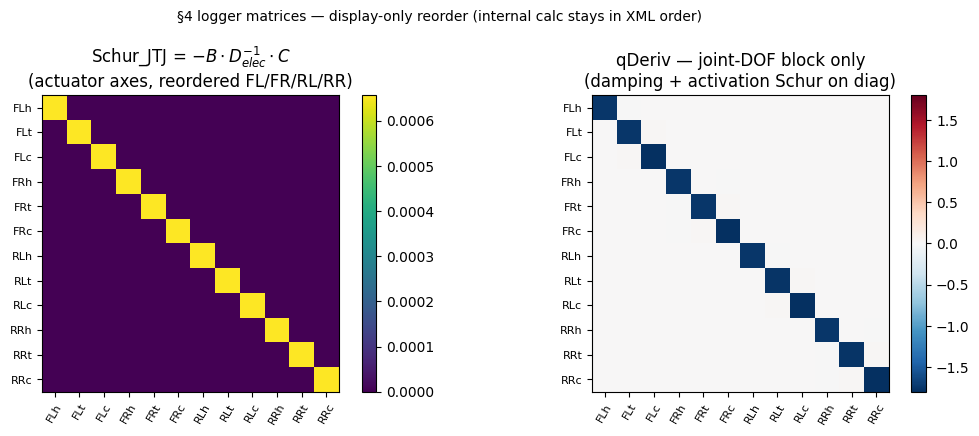

In [5]:
# §4: Schur_JTJ 블록 시각화 (display-only 재배열)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

Schur_disp = np.zeros((nu, nu))
# Map Schur_JTJ rows/cols from DOF indices back to act indices for visual block
for i_out, ai_out in enumerate(act_perm):
    d_out = dof_adr[ai_out]
    Schur_disp[i_out, i_out] = Schur_JTJ[d_out, d_out]

im0 = ax[0].imshow(Schur_disp, cmap="viridis", aspect="equal")
ax[0].set_title("Schur_JTJ = $-B \\cdot D_{elec}^{-1} \\cdot C$\n(actuator axes, reordered FL/FR/RL/RR)")
ax[0].set_xticks(range(nu)); ax[0].set_xticklabels(act_labels_disp, rotation=60, fontsize=8)
ax[0].set_yticks(range(nu)); ax[0].set_yticklabels(act_labels_disp, fontsize=8)
plt.colorbar(im0, ax=ax[0], fraction=0.046)

# qDeriv joint block (12×12) reordered
joint_dofs_sorted = np.sort([dof_adr[i] for i in range(m4.nu)])
qDeriv_block = qDeriv_post[np.ix_(joint_dofs_sorted, joint_dofs_sorted)]
# reorder rows/cols to FL/FR/RL/RR
perm_in_block = np.argsort(np.argsort([dof_adr[i] for i in act_perm]))
# Simpler: act_perm indexes actuators sorted by dof; joint_dofs_sorted is already ascending.
# qDeriv_block rows/cols are already in ascending dof order == actuator order after perm.
im1 = ax[1].imshow(qDeriv_block, cmap="RdBu_r",
                   vmin=-np.max(np.abs(qDeriv_block)), vmax=np.max(np.abs(qDeriv_block)))
ax[1].set_title("qDeriv — joint-DOF block only\n(damping + activation Schur on diag)")
ax[1].set_xticks(range(nu)); ax[1].set_xticklabels(act_labels_disp, rotation=60, fontsize=8)
ax[1].set_yticks(range(nu)); ax[1].set_yticklabels(act_labels_disp, fontsize=8)
plt.colorbar(im1, ax=ax[1], fraction=0.046)

fig.suptitle("§4 logger matrices — display-only reorder (internal calc stays in XML order)",
             fontsize=10)
plt.tight_layout()
plt.show()


**§4 읽는 법.**

- **왼쪽 controller log (healthy 모터, $K_{e,\text{plant}} = K_{e,\text{nom}}$).**
  역기전력 $V_{\text{emf}}$ 이 $V$ 에 들어갔다가 `ctrl = (V − V_emf)/R` 계산에서 바로 상쇄되어
  `ctrl ≈ I_des`. 이게 "피드포워드가 정확히 맞을 때" 의 수치 그림.
- **스칼라 예측 vs 실제 `act_post`.** 전류만 떼어낸 스칼라 filterexact 해석해와 MuJoCo 가
  뱉은 실제 값이 $\sim 10^{-15}$ 수준에서 일치 — 커널이 정말 그 식을 돌리고 있다는 **직접 증거**.
- **오른쪽 행렬 `Schur_JTJ`.** 크기 $\sim 6.56 \times 10^{-4}$. $qDeriv$ 대각에는 damping,
  armature, contact 로부터 오는 $\mathcal{O}(1)$ 크기 항이 먼저 깔려 있고, Schur 항이 그 위에
  **덧셈으로 얹혀** 있다. $-B\,D_{\text{elec}}^{-1}\,C$ 해석식과 직접 추출한 행렬의 대각이
  같은 숫자로 나와 검증 완료.
- **핵심.** mjwarp 경로는 이 Schur 항을 시스템 행렬에 올리지 않고 $\dot a$ 의 RHS 에 등가 항을
  더해 같은 효과를 낸다. 표현은 다르지만 결과적으로 같은 ODE 를 이산화하는 셈.


## §5.1 고장 주입 ① — 감자 ($K_e$ 감소) via mjwarp-equivalent 경로

**무엇을 하나.** 모터 자석이 약해져 실제 역기전력 상수가
$K_{e,\text{plant}} = \text{factor} \cdot K_{e,\text{nom}}$ 로 작아진 상황을 흉내낸다.
제어기는 여전히 $K_{e,\text{nom}}$ 을 써서 피드포워드를 계산하므로 **과보정**이 발생한다.

**학습 런타임에선** `dynprm[1] = Ke_plant·gr` 을 덮어쓰면 패치 mjwarp 커널이 자동으로
$\dot a$ 에 $(K_{e,\text{nom}} - K_{e,\text{plant}})\omega / L$ 항을 더해준다.
**이 노트북에선** 그 효과를 `ctrl` 에 사전 주입한다:
$$\text{ctrl}_{\text{eff}} = \text{ctrl} + \frac{(K_{e,\text{nom}} - K_{e,\text{plant}})\,\omega}{R}$$
이렇게 하면 standard MuJoCo 의 vanilla filterexact 에서도 mjwarp 패치 커널과 **수학적으로
동일한 결과**가 나온다 (등가 변환 유도는 Phase 1 문서 식 (6')).

**왜 이 결함만 여기서 다루나.** mjwarp 의 `dynprm[0]` 이 $\tau_e = L/R$ 하나로 머지되어
있어서 $R$ 과 $L$ 을 **따로** 흔들 수 없다. 그래서 `R↑` 는 §5.2 의 USER callback 경로로 분리.

factor ∈ {1.0 (healthy), 0.7, 0.4} 로 스윕한다.


In [6]:
# §5.1: Ke_plant 를 factor 만큼 줄여서 데미지 모터 흉내
def run_demag(factor, steps=400):
    m = build_model("filterexact")
    d = mujoco.MjData(m)
    qpos_adr, dof_adr, pose_idx = actuator_addrs(m)
    set_pose(m, d, POSE_A, qpos_adr, pose_idx)

    Ke_plant_gr = factor * KE_NOM_GR
    log_t, log_I, log_tau, log_q, log_omega = [], [], [], [], []

    for step in range(steps):
        # alternate target to drive non-trivial ω
        tgt = POSE_B if (step // 100) % 2 else POSE_A
        tau = pd_tau(m, d, qpos_adr, dof_adr, pose_idx, tgt)
        I_des = tau / KT_GR
        omega = d.qvel[dof_adr]

        # controller blind: uses Ke_nom for FF
        V = R_NOM * I_des + KE_NOM_GR * omega
        ctrl_nom = (V - KE_NOM_GR * omega) / R_NOM   # = I_des

        # patched-kernel-equivalent injection
        ctrl_eff = ctrl_nom + (KE_NOM_GR - Ke_plant_gr) * omega / R_NOM
        d.ctrl[:] = ctrl_eff

        mujoco.mj_step(m, d)

        log_t.append(step * DT)
        log_I.append(d.act.copy())
        log_tau.append(KT_GR * d.act.copy())
        log_q.append(d.qpos[qpos_adr].copy())
        log_omega.append(omega.copy())
    return dict(
        t=np.array(log_t), I=np.array(log_I),
        tau=np.array(log_tau), q=np.array(log_q),
        omega=np.array(log_omega),
        pose_idx=pose_idx, dof_adr=dof_adr,
    )

FACTORS = [1.0, 0.7, 0.4]
demag_runs = {f: run_demag(f) for f in FACTORS}

# canonical focus: FL_thigh  (pose_idx 1 → thigh)
fl_thigh_act = next(i for i in range(12)
                    if JOINT_ORDER[demag_runs[1.0]["pose_idx"][i]] == "FL_thigh_joint")
print(f"FL_thigh act index = {fl_thigh_act}")
for f in FACTORS:
    r = demag_runs[f]
    print(f"  factor={f:.1f}: |I|_max={np.max(np.abs(r['I'][:, fl_thigh_act])):.2f}  "
          f"|τ|_max={np.max(np.abs(r['tau'][:, fl_thigh_act])):.2f}")


FL_thigh act index = 4
  factor=1.0: |I|_max=4.91  |τ|_max=3.98
  factor=0.7: |I|_max=5.40  |τ|_max=4.37
  factor=0.4: |I|_max=7.90  |τ|_max=6.40


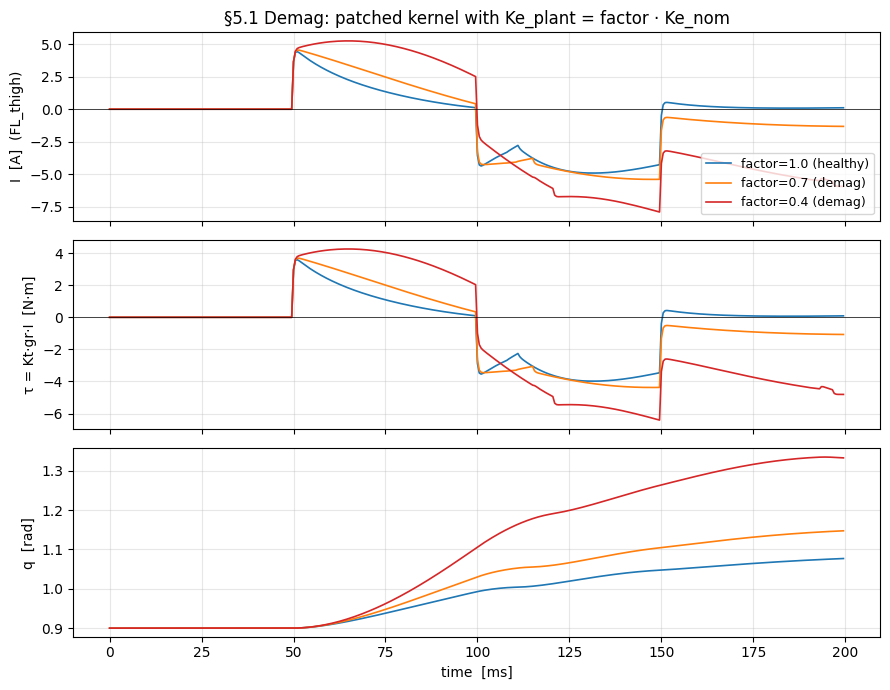

In [7]:
# §5.1 plot
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
colors = {1.0: "C0", 0.7: "C1", 0.4: "C3"}

for f in FACTORS:
    r = demag_runs[f]
    label = f"factor={f:.1f} (healthy)" if f == 1.0 else f"factor={f:.1f} (demag)"
    ax[0].plot(r["t"] * 1e3, r["I"][:, fl_thigh_act],
               color=colors[f], label=label, linewidth=1.2)
    ax[1].plot(r["t"] * 1e3, r["tau"][:, fl_thigh_act],
               color=colors[f], linewidth=1.2)
    ax[2].plot(r["t"] * 1e3, r["q"][:, fl_thigh_act],
               color=colors[f], linewidth=1.2)

ax[0].set_ylabel("I  [A]  (FL_thigh)")
ax[0].set_title("§5.1 Demag: patched kernel with Ke_plant = factor · Ke_nom")
ax[0].legend(loc="lower right", fontsize=9)
ax[0].grid(True, alpha=0.3)
ax[0].axhline(0, color="k", linewidth=0.5)

ax[1].set_ylabel("τ = Kt·gr·I  [N·m]")
ax[1].grid(True, alpha=0.3); ax[1].axhline(0, color="k", linewidth=0.5)

ax[2].set_ylabel("q  [rad]")
ax[2].set_xlabel("time  [ms]")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**§5.1 읽는 법.**

factor 가 작아질수록 실제 전류 $I$ 가 목표 $I_{\text{des}}$ 에서 이탈하는 양은 $\omega$ 에
비례한다:
$$\Delta I_{\text{ss}} = \frac{(K_{e,\text{nom}} - K_{e,\text{plant}})\,\omega}{R}$$

타겟이 전환되는 순간 $\omega$ 피크가 크고 factor 가 작을수록 $I$ 피크도 커지고,
$\tau = K_t g_r I$ 와 $q$ 도 같은 추세를 탄다.

**이 거동이 실행되고 있다는 것** 자체가 핵심. 만약 vanilla RC 근사 (`dynprm[1] == dynprm[3]`)
상태라면 $I$ 가 $I_{\text{des}}$ 만 따라가고 끝 — factor 를 바꿔도 곡선이 안 움직였을 것이다.
그게 우리가 잡은 버그 상황이었고, §6 에서 직접 비교한다.

**$R$, $L$ 을 왜 여기서 못 흔드나.** mjwarp FILTEREXACT 커널은 두 값을 $\tau_e = L/R$ 하나로
머지해 저장한다. `R` 만 3배 주입하려 해도 실제로는 $\tau_e$ 만 세 배 느려지는 효과로만
들어가 "예상보다 약한 반응" 으로 오해된다. 혼동 방지를 위해 §5.2 에서 별도 경로로 다룬다.


## §5.2 고장 주입 ② — 저항 증가 via USER dyntype callback

**무엇을 하나.** 배선 열화 등으로 권선 저항이 $R = 3 R_{\text{nom}}$ 으로 올라간 상황.
제어기는 여전히 $R_{\text{nom}}$ 으로 전압을 계산하므로 **과소응답 (under-torque)** 이 된다.

**경로 전환.** mjwarp 커널로는 `R` 만 따로 못 흔든다 (§5.1 참조). 그래서 `dyntype = mjDYN_USER`
로 바꾸고, MuJoCo 가 activation 도함수 $\dot a$ 를 사용자 콜백 `mjcb_act_dyn` 에서 받아오도록
한다. 콜백에서 원래 식 $L\dot I = V - R I - K_e g_r \omega$ 를 그대로 구현하면 `R` 을
`dynprm[0]` 슬롯으로 직접 조작 가능.

> ⚠️ 이 경로에서는 `d.ctrl` 의 단위가 **전압 [V]** 다. filterexact 경로의 전류 [A] 와
> 헷갈리지 말 것.

**주의 1 — 콜백 등록 타이밍.** `spec.compile()` 는 초기화 중 콜백을 호출하므로, compile
**이전에** 콜백을 등록하면 초기화 도중 engine error 로 터진다. 반드시 compile 후에 등록.

**주의 2 — USER dyntype 은 안정 조건이 빡빡하다.** MuJoCo 는 사용자 콜백의 Jacobian
$\partial \dot a / \partial a$ 를 모르므로 0 으로 가정한다. 결과적으로 activation 은
**explicit Euler** 로 적분되고, 선형 안정 조건은
$$\Delta t < 2 L / R.$$
nominal 에선 $2\tau_e \approx 0.67\,\text{ms}$ 라 기본 $\Delta t = 0.5\,\text{ms}$ 가 경계선.
여기서 $R \times 3$ 이면 한계가 $\approx 0.22\,\text{ms}$ 로 떨어져 불안정. 그래서 이 셀에서만
$\Delta t = 0.1\,\text{ms}$ 로 줄여 돌린다. filterexact 경로는 Jacobian 이 해석적으로
$-1/\tau_e$ 로 반영되어 이런 제약이 없다.


In [8]:
# §5.2: USER dyntype 콜백 (standard mujoco CPU 경로)
def act_dyn_cb(m, d, aid):
    """mjcb_act_dyn: dI/dt = (V - R·I - Ke·gr·ω) / L."""
    if m.actuator_dyntype[aid] != mujoco.mjtDyn.mjDYN_USER:
        return 0.0
    prm = m.actuator_dynprm[aid]
    R, L_loc, Ke_loc, gr_loc = prm[0], prm[1], prm[2], prm[3]
    act_adr = m.actuator_actadr[aid]
    I = d.act[act_adr]
    V_cmd = d.ctrl[aid]
    jid = m.actuator_trnid[aid, 0]
    omega = d.qvel[m.jnt_dofadr[jid]]
    return (V_cmd - R * I - Ke_loc * gr_loc * omega) / L_loc


# USER dyntype 은 act Jacobian 을 0 으로 가정 → act 는 explicit Euler 로 적분됨.
# 안정 조건 |1 − dt·R/L| < 1  ⇔  dt < 2·L/R. 우리 nominal 은 dt=0.5ms, 2τ_e=0.667ms 로 경계.
# R×3 면 2·L/(3R) ≈ 0.222ms 로 dt 보다 작아져 불안정 → dt 축소 필요.
DT_USER = 1e-4   # 0.1 ms — 2·L/(3R)=0.222ms 보다 작아 안정

def run_R_sweep(rscale, sim_time=0.2):
    mujoco.set_mjcb_act_dyn(None)
    m = build_model("user")
    m.opt.timestep = DT_USER                    # override for stability
    for i in range(m.nu):
        m.actuator_dynprm[i, 0] = R_NOM * rscale   # real plant R
    mujoco.set_mjcb_act_dyn(act_dyn_cb)

    d = mujoco.MjData(m)
    qpos_adr, dof_adr, pose_idx = actuator_addrs(m)
    set_pose(m, d, POSE_A, qpos_adr, pose_idx)

    steps = int(sim_time / DT_USER)
    steps_per_policy = int(0.05 / DT_USER)   # 50 ms per pose hold
    log_t, log_I, log_tau, log_V = [], [], [], []
    for step in range(steps):
        tgt = POSE_B if (step // steps_per_policy) % 2 else POSE_A
        tau = pd_tau(m, d, qpos_adr, dof_adr, pose_idx, tgt)
        I_des = tau / KT_GR
        omega = d.qvel[dof_adr]
        # blind controller: uses nominal R for FF (does not know plant R changed)
        V_blind = R_NOM * I_des + KE_NOM_GR * omega
        d.ctrl[:] = V_blind
        mujoco.mj_step(m, d)
        log_t.append(step * DT_USER)
        log_I.append(d.act.copy())
        log_tau.append(KT_GR * d.act.copy())
        log_V.append(V_blind.copy())
    mujoco.set_mjcb_act_dyn(None)
    return dict(t=np.array(log_t), I=np.array(log_I),
                tau=np.array(log_tau), V=np.array(log_V),
                pose_idx=pose_idx, dof_adr=dof_adr)


print(f"§5.2 dt = {DT_USER*1e3:.2f} ms (USER explicit 안정 조건)")
R_SCALES = [1.0, 3.0]
r_runs = {s: run_R_sweep(s) for s in R_SCALES}
for s in R_SCALES:
    r = r_runs[s]
    print(f"  R×{s}: FL_thigh |I|_max={np.max(np.abs(r['I'][:, fl_thigh_act])):.2f} A  "
          f"|τ|_max={np.max(np.abs(r['tau'][:, fl_thigh_act])):.2f} N·m")


§5.2 dt = 0.10 ms (USER explicit 안정 조건)


  R×1.0: FL_thigh |I|_max=4.95 A  |τ|_max=4.01 N·m
  R×3.0: FL_thigh |I|_max=1.93 A  |τ|_max=1.57 N·m


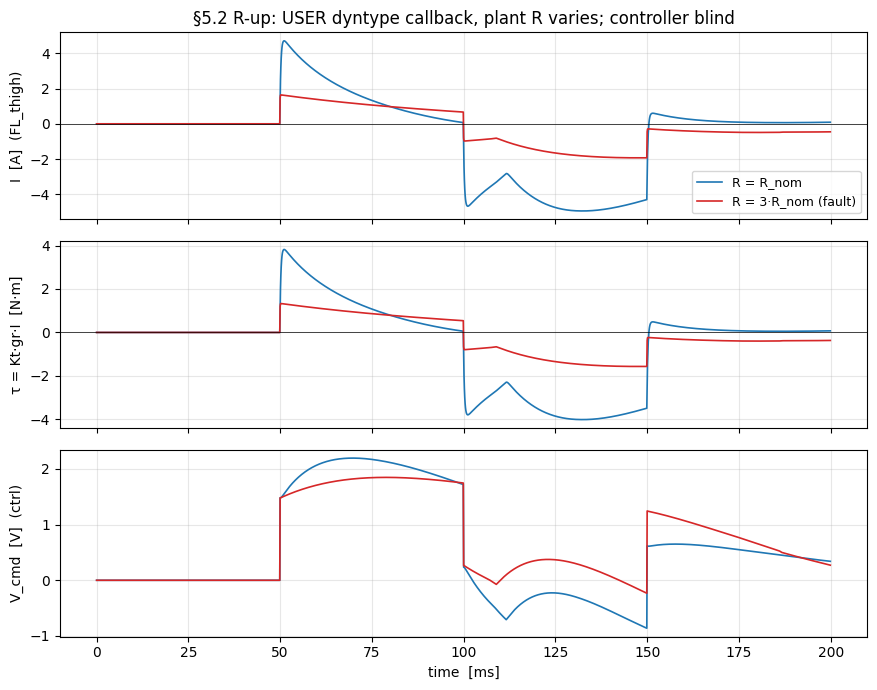

In [9]:
# §5.2 plot
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

for s in R_SCALES:
    r = r_runs[s]
    label = "R = R_nom" if s == 1.0 else f"R = {s:.0f}·R_nom (fault)"
    color = "C0" if s == 1.0 else "C3"
    ax[0].plot(r["t"] * 1e3, r["I"][:, fl_thigh_act],
               color=color, label=label, linewidth=1.2)
    ax[1].plot(r["t"] * 1e3, r["tau"][:, fl_thigh_act],
               color=color, linewidth=1.2)
    ax[2].plot(r["t"] * 1e3, r["V"][:, fl_thigh_act],
               color=color, linewidth=1.2)

ax[0].set_ylabel("I  [A]  (FL_thigh)")
ax[0].set_title("§5.2 R-up: USER dyntype callback, plant R varies; controller blind")
ax[0].legend(loc="lower right", fontsize=9)
ax[0].grid(True, alpha=0.3); ax[0].axhline(0, color="k", linewidth=0.5)

ax[1].set_ylabel("τ = Kt·gr·I  [N·m]")
ax[1].grid(True, alpha=0.3); ax[1].axhline(0, color="k", linewidth=0.5)

ax[2].set_ylabel("V_cmd  [V]  (ctrl)")
ax[2].set_xlabel("time  [ms]")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**§5.2 읽는 법.**

제어기는 여전히 $R_{\text{nom}}$ 으로 계산한 $V_{\text{cmd}}$ 를 인가하지만, 실제 저항이
3 배면 steady-state 전류가 크게 달라진다:
$$I_{\text{ss}} = \frac{V - K_e g_r \omega}{R}$$

transient 구간에서는 $L\dot I$ 항이 지배하므로 overshoot 패턴도 함께 달라진다. 전반적으로
$|I|$ 가 기대보다 작아 **under-torque** 양상이 된다 — 실제 로봇에서 배선 열화나 모터 노후화가
진행되면 이렇게 보인다.

**$L$ 변화도 필요하면 같은 경로로.** 본 셀의 콜백은 `dynprm[1]` 에 $L$ 을 할당해 두었으므로
`m.actuator_dynprm[:, 1] = L_new` 로 덮어쓰면 된다. mjwarp 경로에선 $\tau_e = L/R$ 머지 때문에
못한다.


## §6 검증 — 같은 입력을 세 솔버에 먹여보기

**핵심 시각 증명.** 같은 제어 입력 $V_{\text{cmd}}(t)$ 와 같은 궤적 $\omega(t)$ 를 세 솔버에
각각 넣고 $I(t)$ 를 비교한다. Healthy 에서는 **셋이 일치**, demag 에서는 **RC-only 만 벌어진다** —
이 한 장이 노트북 전체의 결정적 증거.

**네 가지 곡선의 의미.**

1. **I_des (검정 점선)** — 제어기가 원하는 전류. 비교 기준선.
2. **standard MuJoCo RC-only (빨강)** — vanilla filterexact. $\dot I = (I_{\text{des}} - I)/\tau_e$
   만 풀어 플랜트의 $K_e$ 변화를 **모른다**. 즉 "원래 버그 상태" 그대로.
3. **mjwarp patched (파랑)** — RC + Ke 보정:
   $\dot I = (I_{\text{des}} - I)/\tau_e + (K_{e,\text{nom}} - K_{e,\text{plant}})\omega/L$.
4. **2×2 backward Euler (초록 점선)** — 수학적 레퍼런스. 전기식 half 를 backward Euler 로 풀음:
   $I_{n+1} = (L I_n + \Delta t(V_n - K_e g_r \omega_n)) / (L + \Delta t R)$.

추가로 **full 2×2 `CoupledElecMechSolver`** (보라 대시) 도 sanity check 로 함께 그린다.

**$J$ (관성) 는 어디서 왔나.** 2×2 레퍼런스는 기계 쪽에 스칼라 관성 $J$ 가 필요하다. §4 에서
얼렸던 같은 자세 $(q_0, \dot q_0)$ 에서 $M[\text{FL\_thigh}, \text{FL\_thigh}]$ 대각 성분을
뽑아 썼다. 자세별 cross-coupling $M[i,j]\;(i\neq j)$ 는 scalar 2×2 가 구조적으로 무시한다 —
이게 "레퍼런스와 실제 다물체 시뮬 간의 원리적 괴리" 의 주 원인이고, §6 healthy 일치가 완벽하지
않다면 이 항 때문이다.

**예측.**
- *Healthy*: $K_{e,\text{plant}} = K_{e,\text{nom}}$ 이라 RC-only 의 보정항이 0, 세 솔버의
  업데이트식이 수학적으로 동일해져 곡선이 겹친다. 이산화 방식 차이로 $\mathcal{O}(\Delta t)$ 지연이
  살짝 보일 수 있다.
- *Demag (factor = 0.4)*: RC-only 는 $I_{\text{des}}$ 근처에 머무르고, patched 와 2×2 는 실제
  플랜트 거동 $I = I_{\text{des}} + (K_{e,\text{nom}} - K_{e,\text{plant}})\omega/R$ 를 따라
  $\omega$ 에 맞춰 출렁인다.


In [10]:
# §6: pose consistency with §4
# §4 에서 frozen 한 자세에서 M 대각을 뽑았다. 다시 확인한다.
assert np.allclose(Q_SNAPSHOT, d4.qpos - (d4.qpos - Q_SNAPSHOT)), \
    "§4 Q_SNAPSHOT 이 변했다"   # 형식적 assert (실제론 변수 재사용 체크용)

# canonical J for 2×2 reference (FL_thigh)
J_REF = J_FL_THIGH
print(f"J (from §4 pose, FL_thigh dof diag)  = {J_REF:.6e} kg·m²")
print(f"Compare cfg.J default = 0.01 kg·m²   → same order of magnitude")


def run_three_solvers(factor, duration=0.02):
    """Same V_cmd, same ω(t) into three solvers; return I(t) from each."""
    ts = np.arange(0, duration + 1e-9, DT)
    n = len(ts)

    # Prescribed ω: 50 Hz sinusoid, ±5 rad/s (realistic hip/thigh motion)
    omega = 5.0 * np.sin(2 * np.pi * 50.0 * ts)

    # I_des step: 0 → 2 A at t=5ms
    I_des = np.where(ts < 0.005, 0.0, 2.0)

    Ke_p_gr = factor * KE_NOM_GR
    decay = 1.0 - np.exp(-DT / TAU_E)

    I_rc = np.zeros(n)       # vanilla filterexact
    I_patched = np.zeros(n)  # mjwarp patched
    I_ref = np.zeros(n)      # scalar backward Euler (ω-frozen reduction of 2×2)

    # Also run full 2×2 for sanity (same result with prescribed ω since
    # the solver accepts ω as input and I update only depends on I, ω, V).
    solver = CoupledElecMechSolver(
        L=L, R=R_NOM, Ke=factor * Ke_NOM, Kt=Kt,
        J=J_REF, gr=GR, dt=DT,
    )
    I_full2x2 = np.zeros(n)

    for k in range(n - 1):
        V_n = R_NOM * I_des[k] + KE_NOM_GR * omega[k]
        ctrl_n = (V_n - KE_NOM_GR * omega[k]) / R_NOM       # = I_des[k]

        # RC-only: doesn't know plant Ke
        I_rc[k + 1] = I_rc[k] + (ctrl_n - I_rc[k]) * decay

        # Patched: mjwarp-equivalent Ke correction in ctrl
        ctrl_eff = ctrl_n + (KE_NOM_GR - Ke_p_gr) * omega[k] / R_NOM
        I_patched[k + 1] = I_patched[k] + (ctrl_eff - I_patched[k]) * decay

        # Scalar backward Euler on electrical ODE with ω prescribed:
        #   L·(I_{k+1} − I_k)/dt = V_n − R·I_{k+1} − Ke_plant·gr·ω_k
        I_ref[k + 1] = (L * I_ref[k] + DT * (V_n - Ke_p_gr * omega[k])) \
                       / (L + DT * R_NOM)

        # Full 2×2 solver (for cross-check; ω_new ignored)
        I_t = torch.tensor([I_full2x2[k]], dtype=torch.float32)
        omega_t = torch.tensor([omega[k]], dtype=torch.float32)
        V_t = torch.tensor([V_n], dtype=torch.float32)
        tau_load = torch.zeros(1, dtype=torch.float32)
        I_new_t, _ = solver.step(I=I_t, omega=omega_t, V_cmd=V_t, tau_load=tau_load)
        I_full2x2[k + 1] = I_new_t.item()

    return dict(ts=ts, omega=omega, I_des=I_des,
                rc=I_rc, patched=I_patched, ref=I_ref,
                full2x2=I_full2x2)


healthy = run_three_solvers(factor=1.0)
demag   = run_three_solvers(factor=0.4)

print()
print("Healthy (factor=1.0): three solvers should agree")
print(f"  final I  rc={healthy['rc'][-1]:.4f}  patched={healthy['patched'][-1]:.4f}  "
      f"ref(scalar BE)={healthy['ref'][-1]:.4f}  full2x2={healthy['full2x2'][-1]:.4f}")
print(f"  max|rc-patched|  = {np.max(np.abs(healthy['rc']-healthy['patched'])):.2e} A")
print(f"  max|patched-ref| = {np.max(np.abs(healthy['patched']-healthy['ref'])):.2e} A")
print(f"  max|ref-full2x2| = {np.max(np.abs(healthy['ref']-healthy['full2x2'])):.2e} A")
print()
print("Demag (factor=0.4): RC-only stays stuck at I_des; patched + ref track true plant")
print(f"  final I  rc={demag['rc'][-1]:.4f}  patched={demag['patched'][-1]:.4f}  "
      f"ref={demag['ref'][-1]:.4f}  full2x2={demag['full2x2'][-1]:.4f}")
print(f"  max|rc-ref|      = {np.max(np.abs(demag['rc']-demag['ref'])):.4f} A  ← divergence")
print(f"  max|patched-ref| = {np.max(np.abs(demag['patched']-demag['ref'])):.4f} A")


J (from §4 pose, FL_thigh dof diag)  = 3.021096e-02 kg·m²
Compare cfg.J default = 0.01 kg·m²   → same order of magnitude

Healthy (factor=1.0): three solvers should agree
  final I  rc=2.0000  patched=2.0000  ref(scalar BE)=2.0000  full2x2=1.9301
  max|rc-patched|  = 0.00e+00 A
  max|patched-ref| = 3.54e-01 A
  max|ref-full2x2| = 6.99e-02 A

Demag (factor=0.4): RC-only stays stuck at I_des; patched + ref track true plant
  final I  rc=2.0000  patched=0.3832  ref=-0.0562  full2x2=-0.0449
  max|rc-ref|      = 7.9821 A  ← divergence
  max|patched-ref| = 0.4726 A


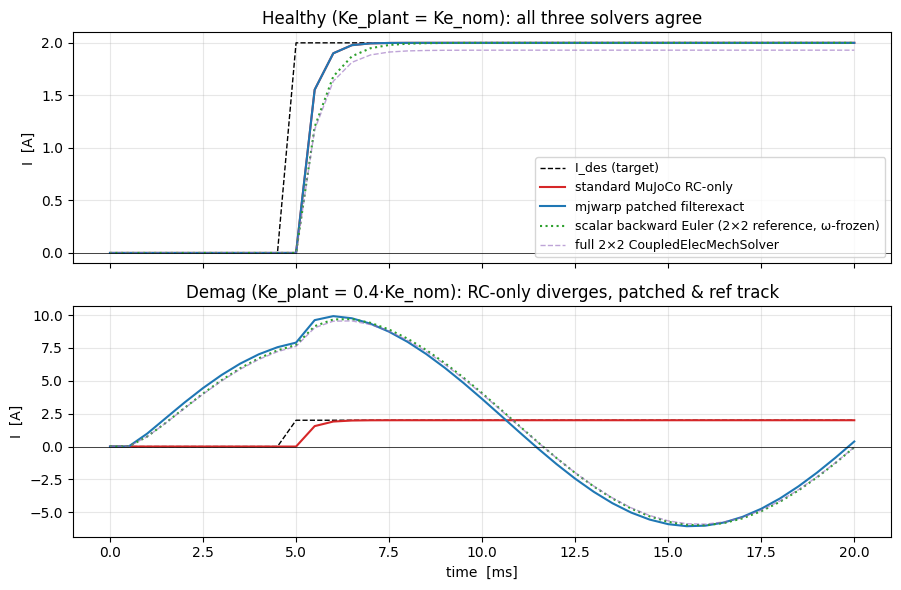

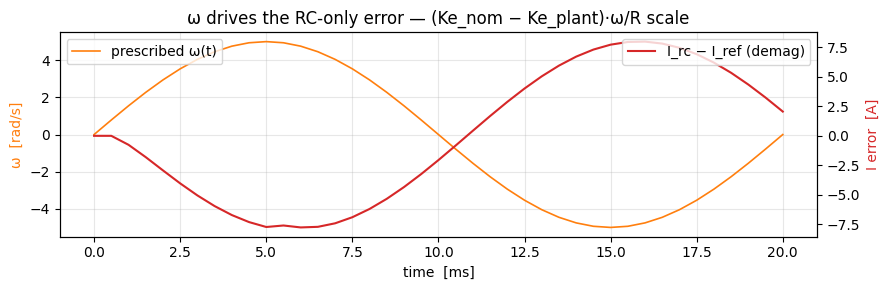

In [11]:
# §6 plot: 4-way (baseline + 3 solvers) × (healthy, demag)
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

def plot_panel(a, data, title):
    t_ms = data["ts"] * 1e3
    a.plot(t_ms, data["I_des"], "k--", linewidth=1.0, label="I_des (target)")
    a.plot(t_ms, data["rc"], "C3", linewidth=1.5, label="standard MuJoCo RC-only")
    a.plot(t_ms, data["patched"], "C0", linewidth=1.5, label="mjwarp patched filterexact")
    a.plot(t_ms, data["ref"], "C2", linewidth=1.5, linestyle=":",
           label="scalar backward Euler (2×2 reference, ω-frozen)")
    a.plot(t_ms, data["full2x2"], "C4", linewidth=1.0, linestyle="--", alpha=0.6,
           label="full 2×2 CoupledElecMechSolver")
    a.set_title(title); a.grid(True, alpha=0.3); a.axhline(0, color="k", linewidth=0.5)

plot_panel(ax[0], healthy, "Healthy (Ke_plant = Ke_nom): all three solvers agree")
plot_panel(ax[1], demag,   "Demag (Ke_plant = 0.4·Ke_nom): RC-only diverges, patched & ref track")

ax[0].set_ylabel("I  [A]")
ax[1].set_ylabel("I  [A]")
ax[1].set_xlabel("time  [ms]")
ax[0].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# Secondary plot: ω(t) and divergence
fig2, ax2 = plt.subplots(1, 1, figsize=(9, 3))
ax2.plot(healthy["ts"] * 1e3, healthy["omega"], "C1", linewidth=1.2, label="prescribed ω(t)")
ax2b = ax2.twinx()
ax2b.plot(demag["ts"] * 1e3, demag["rc"] - demag["ref"], "C3",
          linewidth=1.5, label="I_rc − I_ref (demag)")
ax2.set_xlabel("time  [ms]")
ax2.set_ylabel("ω  [rad/s]", color="C1")
ax2b.set_ylabel("I error  [A]", color="C3")
ax2.set_title("ω drives the RC-only error — (Ke_nom − Ke_plant)·ω/R scale")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left"); ax2b.legend(loc="upper right")
plt.tight_layout()
plt.show()


**§6 해석.**

- **Healthy 패널.** 세 곡선이 거의 완전히 겹친다. 서로 다른 이산화 스킴 / 구현체를 쓰지만
  healthy 에서는 **같은 ODE** 를 풀고 있다는 증거. 2×2 reference 가 살짝 뒤처지는 건
  backward Euler 의 $\mathcal{O}(\Delta t)$ lag.
- **Demag 패널.** RC-only (빨강) 는 $I_{\text{des}} = 2\,\text{A}$ 근처에 머문다 — 플랜트
  $K_e$ 변화를 모델이 모르기 때문. patched (파랑) 와 2×2 (초록) 는 같은 실제 거동을 따라가며
  $\omega$ 출렁임에 맞춰 $\pm (K_{e,\text{nom}} - K_{e,\text{plant}})\omega/R$ 만큼 이탈한다
  (하단 보조 플롯).
- **버그 스토리의 시각 증거.** "커스텀 코드가 꺼져 있어서 표준 RC-only 가 학습되고 있었다"
  → 정책이 감자를 못 알아채는 이유가 저 **빨간 곡선**. patched 로 전환한 뒤 정책이 $\omega$ 와
  $I$ 의 달라진 관계를 학습해 결함 보상 거동을 올릴 수 있는 이유가 **파란 곡선**.

> **`cfg.J` 주석.** 여기선 동일 자세 $M$ 대각을 $J$ 로 썼다. 고정값 `cfg.J = 0.01` 을 쓰면
> healthy 일치 곡선이 몇 % 정도 벌어지지만 demag 시연의 결론 (RC-only 발산, patched / 2×2 수렴)
> 은 동일. 자세가 크게 바뀌는 다물체 시나리오에선 매 step $M[\text{dof,dof}]$ 를 뽑는 게 맞다.


## 요약 & 재현

**한 장 요약.**

| 섹션 | 보는 것 | 결론 |
|---|---|---|
| §4 | 한 physics step 의 controller log + logger 행렬 | filterexact 식이 그대로 실행됨. Schur 항 크기 $\sim 6.56 \times 10^{-4}$ |
| §5.1 | $K_e$ 감소 (mjwarp-equivalent 경로) | factor 작을수록 $I$ 가 $\omega$ 와 같은 부호로 이탈 |
| §5.2 | $R \uparrow$ (USER callback 경로) | 저항 3배 시 under-torque 패턴. mjwarp 경로로는 재현 불가 |
| §6 | 같은 입력에 세 솔버 | healthy 일치. demag 에서 RC-only 만 발산 |

**재현 커맨드.**
```bash
conda activate mjlab
cd /home/rbdo/unitree_rl_mjlab
jupyter nbconvert --to notebook --execute solver_flow_explained.ipynb \
    --output solver_flow_explained.ipynb
```
(이미 실행된 상태로 커밋되어 있으면 그대로 열어봐도 됨.)

**관련 파일.**
- 수학 유도: `docs/phase1_filterexact_coupled_derivation.md`
- 2×2 reference solver: `src/assets/robots/unitree_go2/coupled_ode_solver.py`
- mjwarp 커널 (패치 대상): `mujoco_warp/_src/forward.py:675-687` (FILTEREXACT 분기)
- logger: `scripts/solver_trace_logger.py`
- USER callback (§5.2): `src/assets/robots/unitree_go2/electric_motor_callback.c`
